# Part 3 — Forward Projector: tests

**Task (from the assignment):** develop a module to project a point from the CK frame onto the detectors.
**Test:** test the projector on 3 suitable points of your choice, explain your choice, predict the result,
run your module and show that it produces the predicted results.

The projector under test is `projector/forward_projector.py` (`forward_project`, `project_point_to_detector`),
using the detector geometry defined in `geometry.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make the repo root importable when the notebook runs from notebooks/
ROOT = Path.cwd() if (Path.cwd() / "projector").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from geometry import DETECTOR_A, DETECTOR_B, SAD, SDD
from projector.forward_projector import forward_project

np.set_printoptions(precision=4, suppress=True)

## 1. Geometry the predictions rely on

From the assignment:

* SAD = 100 cm = **1000 mm**, SDD = 200 cm = **2000 mm**, so a point at the isocentre is magnified exactly
  **SDD / SAD = 2**.
* Home position: detector $+v$ = CK $+x$, detector $+w$ = CK $+y$, and $+w$ always points to the X-ray source,
  so the home source sits at $(0, +1000, 0)$ and the home detector centre at $(0, -1000, 0)$.
* Detector $+u$ = CK $+z$ always.
* Pose **A** = home rotated **+45°** about $+z$; pose **B** = **−45°**. The two beams are therefore
  **perpendicular** to each other, and both central rays pass through the CK origin.

The module builds exactly this geometry:

In [2]:
for name, d in [("A", DETECTOR_A), ("B", DETECTOR_B)]:
    print(f"Detector {name}: source={d['source']}  centre={d['center']}")
    print(f"            u={d['u']}  v={d['v']}  w={d['w']}\n")

Detector A: source=[-707.1068  707.1068    0.    ]  centre=[ 707.1068 -707.1068    0.    ]
            u=[0. 0. 1.]  v=[0.7071 0.7071 0.    ]  w=[-0.7071  0.7071  0.    ]

Detector B: source=[707.1068 707.1068   0.    ]  centre=[-707.1068 -707.1068    0.    ]
            u=[0. 0. 1.]  v=[ 0.7071 -0.7071  0.    ]  w=[0.7071 0.7071 0.    ]



## 2. How to predict a projection by hand

Take a point $P$ and one detector with source $S$ and axes $u, v, w$.

* **Depth.** $d = P \cdot w$ is how far $P$ sits from the isocentre *towards the source*.
  The distance from the source to the plane through $P$ (parallel to the detector) is $SAD - d$.
* **Magnification (similar triangles).** The detector is $SDD$ from the source, so
  $$M = \frac{SDD}{SAD - d} = \frac{2000}{1000 - P\cdot w}.$$
  At the isocentre plane ($d = 0$) this is exactly 2; points closer to the source are magnified more.
* **Position on the detector.** The sideways offsets of $P$ are scaled by $M$:
  $$u = M\,(P\cdot u) = M\,P_z, \qquad v = M\,(P\cdot v), \qquad w = 0 \;(\text{the hit lies on the detector plane}).$$

This is a different calculation from the module (which intersects a ray with the detector plane),
so agreement between the two is a genuine check.

## 3. The three test points, why they were chosen, and the predictions

Each point is chosen to test one property of the projector, with an answer that can be predicted with mental arithmetic.

### Point 1 — the isocentre $P_1 = (0, 0, 0)$
*Why:* both central rays pass through the CK origin, so it must land on the **centre of both detectors**.
This checks that the source, the isocentre and the detector centre are lined up for both poses.

*Prediction:* A: $(u, v) = (0, 0)$, B: $(u, v) = (0, 0)$.

### Point 2 — on the rotation axis $P_2 = (0, 0, 50)$
*Why:* a point on the $z$ axis is equidistant from both sources ($d = 0$ for both), so the magnification is
**exactly 2** on both detectors, and it has no sideways offset in the rotation plane. This checks the
**magnification** and that detector $+u$ is CK $+z$ (it should move *up* the detector, not down or sideways).

*Prediction:* $M = 2$, $u = 2 \times 50 = 100$, $v = 0$ on both: A $(100, 0)$, B $(100, 0)$.

### Point 3 — off-axis, exploiting the perpendicular beams $P_3 = 10\,\hat v_A + 50\,\hat z = (7.071, 7.071, 50)$
*Why:* because the beams are perpendicular, A's $v$ direction is B's beam direction. So this single point tests
three things at once:

* On **A** it is sideways to the beam ($P\cdot w_A = 0$), i.e. in A's isocentre plane, so $M_A = 2$ exactly and
  $v_A = 2 \times 10 = +20$. This checks the **sign/direction of $+v$**.
* On **B** it lies in the vertical plane of B's central ray ($P\cdot v_B = 0$), so $v_B = 0$.
* It is 10 mm **closer to B's source** ($P\cdot w_B = 10$), so $M_B = 2000/990 = 2.0202$ and
  $u_B = 50 \times 2.0202 = 101.01$, slightly larger than $u_A = 100$. This checks that
  **magnification changes with depth**.

*Prediction:* A $(100, 20)$, B $(101.01, 0)$.

In [3]:
s = np.sqrt(0.5)

tests = {
    "P1 isocentre":          np.array([0.0, 0.0, 0.0]),
    "P2 on z-axis":          np.array([0.0, 0.0, 50.0]),
    "P3 10 along v_A, z=50": np.array([10 * s, 10 * s, 50.0]),
}

# Hand predictions (u, v) in mm, written down before running the module
predicted = {
    "P1 isocentre":          {"A": [0.0, 0.0],   "B": [0.0, 0.0]},
    "P2 on z-axis":          {"A": [100.0, 0.0], "B": [100.0, 0.0]},
    "P3 10 along v_A, z=50": {"A": [100.0, 20.0], "B": [50 * 2000 / 990, 0.0]},
}

A top view (looking down CK $-z$) of the set-up, with the rays through $P_3$. The point is tiny on this scale,
so the inset shows where it sits: on A's isocentre plane and on B's central ray.

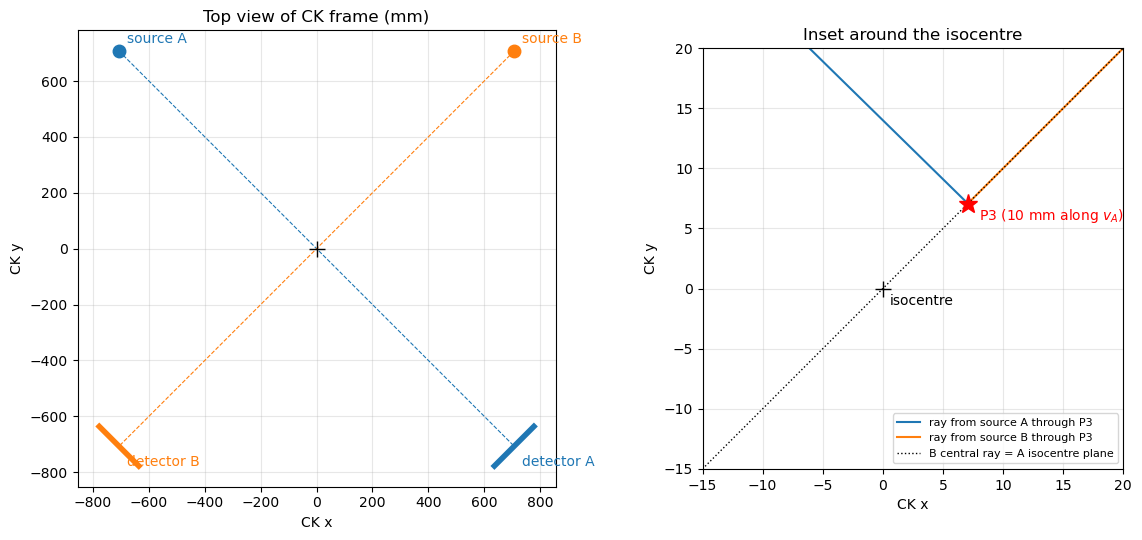

In [4]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={"width_ratios": [1.4, 1]})

for name, d, col in [("A", DETECTOR_A, "tab:blue"), ("B", DETECTOR_B, "tab:orange")]:
    S, C, v = d["source"], d["center"], d["v"]
    half = 100.0 * v                       # detector is 200 mm wide
    ax.plot(*S[:2], "o", color=col, ms=9)
    ax.annotate(f"source {name}", S[:2], textcoords="offset points", xytext=(6, 6), color=col)
    ax.plot(*np.c_[C - half, C + half][:2], color=col, lw=4)
    ax.annotate(f"detector {name}", C[:2], textcoords="offset points", xytext=(6, -14), color=col)
    ax.plot(*np.c_[S, C][:2], "--", color=col, lw=0.8)           # central ray
    P = tests["P3 10 along v_A, z=50"]
    ax2.plot(*np.c_[S, P][:2], color=col, lw=1.5, label=f"ray from source {name} through P3")

ax.plot(0, 0, "k+", ms=12)
ax.set(title="Top view of CK frame (mm)", xlabel="CK x", ylabel="CK y", aspect="equal")
ax.grid(alpha=0.3)

P = tests["P3 10 along v_A, z=50"]
ax2.plot([-15, 20], [-15, 20], "k:", lw=1, label="B central ray = A isocentre plane")
ax2.plot(0, 0, "k+", ms=12); ax2.annotate("isocentre", (0, 0), textcoords="offset points", xytext=(5, -12))
ax2.plot(*P[:2], "r*", ms=14); ax2.annotate("P3 (10 mm along $v_A$)", P[:2], textcoords="offset points",
                                            xytext=(8, -12), color="r")
ax2.set(title="Inset around the isocentre", xlabel="CK x", ylabel="CK y", aspect="equal",
        xlim=(-15, 20), ylim=(-15, 20))
ax2.legend(loc="lower right", fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Run the module and compare with the predictions

In [5]:
rows = []
all_ok = True
for name, P in tests.items():
    result = forward_project(P)
    for det in ("A", "B"):
        got = result[det]                          # (u, v, w) in mm
        pred = np.array(predicted[name][det])
        ok = np.allclose(got[:2], pred, atol=1e-9) and abs(got[2]) < 1e-9
        all_ok &= ok
        rows.append((name, det, pred, got, ok))

print(f"{'point':24s}{'det':5s}{'predicted (u, v)':>22s}{'module (u, v, w)':>34s}  match")
for name, det, pred, got, ok in rows:
    print(f"{name:24s}{det:5s}{np.array2string(pred, precision=4):>22s}"
          f"{np.array2string(got, precision=4, suppress_small=True):>34s}  {'yes' if ok else 'NO'}")

print("\nAll predictions reproduced:", all_ok)
assert all_ok

point                   det        predicted (u, v)                  module (u, v, w)  match
P1 isocentre            A                   [0. 0.]                        [0. 0. 0.]  yes
P1 isocentre            B                   [0. 0.]                        [0. 0. 0.]  yes
P2 on z-axis            A               [100.   0.]                  [100.   0.   0.]  yes
P2 on z-axis            B               [100.   0.]                  [100.   0.   0.]  yes
P3 10 along v_A, z=50   A               [100.  20.]                  [100.  20.  -0.]  yes
P3 10 along v_A, z=50   B       [101.0101   0.    ]      [101.0101  -0.      -0.    ]  yes

All predictions reproduced: True


## 5. Findings

* **P1:** the isocentre lands on the centre of both detectors, so both poses are aligned (source, isocentre and
  detector centre are collinear).
* **P2:** a point 50 mm up the $z$ axis lands 100 mm up both detectors: the magnification at the isocentre is 2 and
  detector $+u$ is CK $+z$, as specified.
* **P3:** on A the point appears at $v = +20$ (correct direction of $+v$, magnification 2 in A's isocentre plane);
  on B it lies on the central-ray plane ($v = 0$) and is magnified slightly more ($u = 101.01$ vs $100$) because it is
  10 mm closer to B's source. The projector handles depth-dependent magnification correctly.
* In every case $w \approx 0$ (to about $10^{-13}$ mm), i.e. the projected point lies on the detector plane.

The module reproduces every hand prediction to within floating-point rounding.

**Scope:** these tests check that the code implements the geometry of Section 1. They rely on the same conventions
(±45° poses, axis directions), so they confirm the implementation matches the assignment's set-up, not the set-up itself.